In [3]:
#Experimenr 5: FC learning rate：1e-3 → 1e-4
import os
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')

# -- Device --
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("We are using device:", device)

# -- Transforms --
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    # data augmentation: 1. flip horizontal 2. rotate five degrees 3. zoom 4. translate
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=5),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -- Settings --
SAVE_PATH = '/content/drive/MyDrive/resnet18_eye_binary.pth'
EPOCHS = 20
LR = 1e-4

# map text labels to binary targets (0 = simple, 1 = complex)
LABEL_MAP = {'simple': 0.0, 'complex': 1.0}

# -- Dataset --
class MakeupDataSet(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        image = Image.open(os.path.join(self.img_dir, row['filename'])).convert('RGB')
        image = self.transform(image)

        # CHANGED: use eye-specific binary label
        label = torch.tensor(
            LABEL_MAP[row['eye_label']],
            dtype=torch.float32
        )

        return image, label

# -- Load data --

# CHANGED: use cropped eye images
IMG_DIR = '/content/drive/MyDrive/makeup/eye'

# CHANGED: use new region-specific binary CSV
CSV_PATH = '/content/complexity_labels_region_binary.csv'

df = pd.read_csv(CSV_PATH)
df["image_path"] = df["filename"].apply(
    lambda x: os.path.join(IMG_DIR, x)
)

missing = df[~df["image_path"].apply(os.path.exists)]

print("Missing images:", len(missing))
print(missing["filename"].tolist())

df = df[df["image_path"].apply(os.path.exists)].copy().reset_index(drop=True)

# CHANGED: use eye_label instead of complexity_label
print(df['eye_label'].value_counts())

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['eye_label']
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))

train_loader = DataLoader(
    MakeupDataSet(train_df, IMG_DIR, train_tf),
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    MakeupDataSet(val_df, IMG_DIR, val_tf),
    batch_size=32,
    shuffle=False
)

# -- Model --
model = models.resnet18(weights='IMAGENET1K_V1')

# output 1 raw logit for binary classification
# BCEWithLogitsLoss applies sigmoid internally
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 1)
)

# freeze everything first, then unfreeze layer4
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

# unfreeze fc
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

# BCEWithLogitsLoss for binary classification
# Experiment 1: NO weighted loss
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    [
        {"params": model.layer4.parameters(), "lr": 1e-5},
        {"params": model.fc.parameters(), "lr": 1e-4},
    ],
    weight_decay=1e-4
)

# -- Training loop --
best_val_acc = 0.0

for epoch in range(EPOCHS):

    # training phase
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(labels)

        preds = (torch.sigmoid(outputs) > 0.5).float()

        train_correct += (preds == labels).sum().item()
        train_total += len(labels)

    # validation phase
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)

            val_loss += criterion(outputs, labels).item() * len(labels)

            preds = (torch.sigmoid(outputs) > 0.5).float()

            val_correct += (preds == labels).sum().item()
            val_total += len(labels)

            all_preds.extend(
                preds.squeeze(1).cpu().numpy()
            )

            all_labels.extend(
                labels.squeeze(1).cpu().numpy()
            )

    train_loss_avg = train_loss / len(train_df)
    val_loss_avg = val_loss / len(val_df)

    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"train_loss: {train_loss_avg:.4f} | "
        f"val_loss: {val_loss_avg:.4f} | "
        f"train_acc: {train_acc:.3f} | "
        f"val_acc: {val_acc:.3f}"
    )

    # save model if val_acc improves
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            SAVE_PATH
        )

        print(
            f"  -> best model saved "
            f"(val_acc={val_acc:.3f})"
        )

print(
    f"\nDone! Best validation accuracy: "
    f"{best_val_acc:.3f}"
)

Mounted at /content/drive
We are using device: cuda
Missing images: 1
['7a6efe107c6d7cdc5dd77d2af63b5bcb.png']
eye_label
complex    1687
simple     1031
Name: count, dtype: int64
Training images: 2174
Validation images: 544
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 219MB/s]


Epoch 01/20 | train_loss: 0.7277 | val_loss: 0.6656 | train_acc: 0.536 | val_acc: 0.625
  -> best model saved (val_acc=0.625)
Epoch 02/20 | train_loss: 0.6656 | val_loss: 0.6536 | train_acc: 0.618 | val_acc: 0.625
Epoch 03/20 | train_loss: 0.6552 | val_loss: 0.6502 | train_acc: 0.631 | val_acc: 0.632
  -> best model saved (val_acc=0.632)
Epoch 04/20 | train_loss: 0.6564 | val_loss: 0.6524 | train_acc: 0.638 | val_acc: 0.618
Epoch 05/20 | train_loss: 0.6216 | val_loss: 0.6499 | train_acc: 0.667 | val_acc: 0.623
Epoch 06/20 | train_loss: 0.6308 | val_loss: 0.6446 | train_acc: 0.649 | val_acc: 0.625
Epoch 07/20 | train_loss: 0.6270 | val_loss: 0.6455 | train_acc: 0.667 | val_acc: 0.621
Epoch 08/20 | train_loss: 0.6193 | val_loss: 0.6437 | train_acc: 0.662 | val_acc: 0.634
  -> best model saved (val_acc=0.634)
Epoch 09/20 | train_loss: 0.6195 | val_loss: 0.6462 | train_acc: 0.672 | val_acc: 0.636
  -> best model saved (val_acc=0.636)
Epoch 10/20 | train_loss: 0.6144 | val_loss: 0.6472 | tr

Step 2. Load the best model

In [4]:
model.load_state_dict(
    torch.load(SAVE_PATH, map_location=device)
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Step 3. Confusion matrix

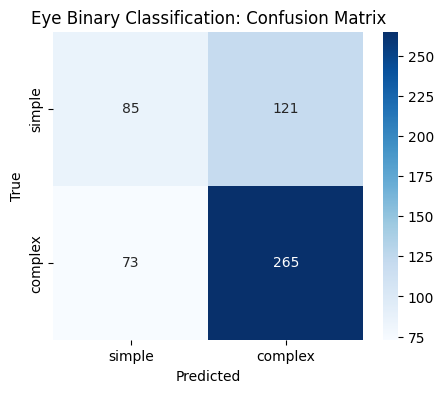

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device).unsqueeze(1)

        outputs = model(images)

        preds = (
            torch.sigmoid(outputs) > 0.5
        ).float()

        all_preds.extend(
            preds.squeeze(1).cpu().numpy()
        )

        all_labels.extend(
            labels.squeeze(1).cpu().numpy()
        )

cm = confusion_matrix(
    all_labels,
    all_preds
)

labels_names = [
    'simple',
    'complex'
]

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=labels_names,
    yticklabels=labels_names,
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('True')

plt.title(
    'Eye Binary Classification: Confusion Matrix'
)

plt.show()

Step 4. Misclassification analysis

True simple -> Predicted complex: 121
True complex -> Predicted simple: 73


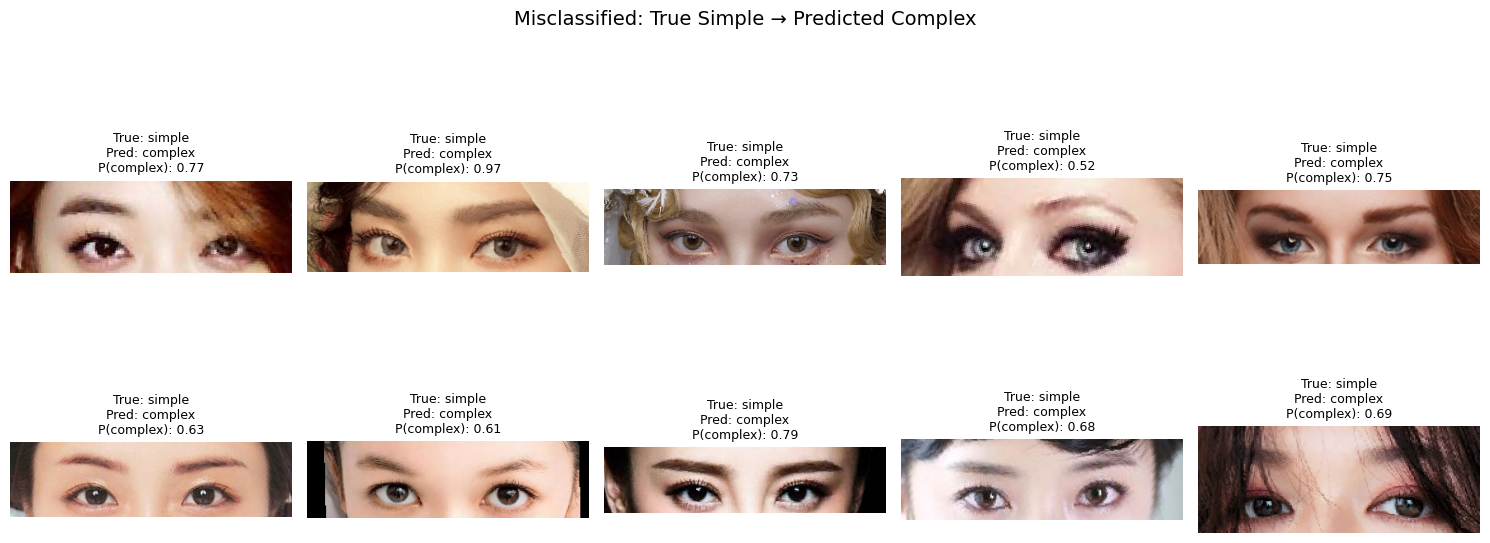

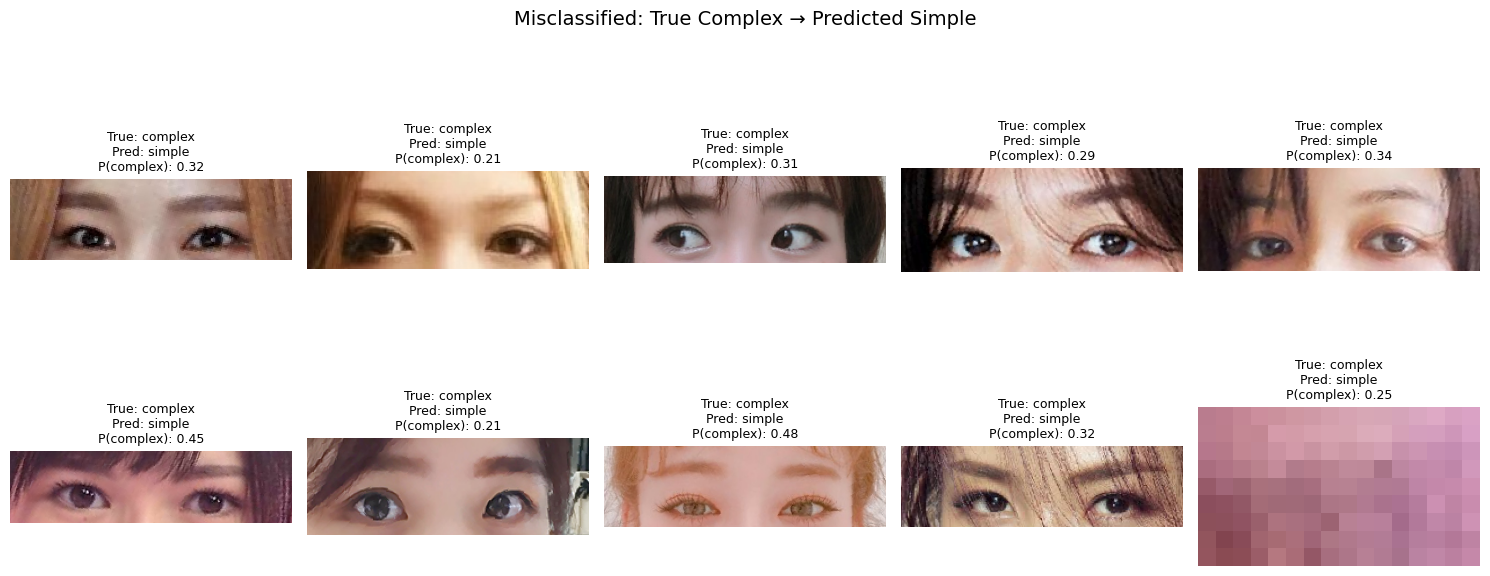

In [6]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# Build a validation dataset that also keeps access to filenames.
error_val_dataset = MakeupDataSet(val_df, IMG_DIR, val_tf)

simple_to_complex = []
complex_to_simple = []

model.eval()

with torch.no_grad():
    for idx in range(len(error_val_dataset)):
        image_tensor, label = error_val_dataset[idx]

        output = model(image_tensor.unsqueeze(0).to(device))
        prob_complex = torch.sigmoid(output).item()
        pred = 1.0 if prob_complex > 0.5 else 0.0
        true_label = float(label.item())

        row = val_df.iloc[idx]
        filename = row["filename"]

        record = {
            "idx": idx,
            "filename": filename,
            "true_label": true_label,
            "pred_label": pred,
            "prob_complex": prob_complex,
        }

        if true_label == 0.0 and pred == 1.0:
            simple_to_complex.append(record)
        elif true_label == 1.0 and pred == 0.0:
            complex_to_simple.append(record)

print("True simple -> Predicted complex:", len(simple_to_complex))
print("True complex -> Predicted simple:", len(complex_to_simple))


def show_error_examples(error_list, title, n=10, seed=42):
    if len(error_list) == 0:
        print(f"No examples found for: {title}")
        return

    random.seed(seed)
    examples = random.sample(error_list, min(n, len(error_list)))

    cols = 5
    rows = (len(examples) + cols - 1) // cols

    plt.figure(figsize=(15, 3.4 * rows))

    for i, ex in enumerate(examples):
        img_path = os.path.join(IMG_DIR, ex["filename"])
        image = Image.open(img_path).convert("RGB")

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.axis("off")

        true_name = "simple" if ex["true_label"] == 0.0 else "complex"
        pred_name = "simple" if ex["pred_label"] == 0.0 else "complex"

        plt.title(
            f"True: {true_name}\n"
            f"Pred: {pred_name}\n"
            f"P(complex): {ex['prob_complex']:.2f}",
            fontsize=9
        )

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


show_error_examples(
    simple_to_complex,
    "Misclassified: True Simple → Predicted Complex",
    n=10,
    seed=42
)

show_error_examples(
    complex_to_simple,
    "Misclassified: True Complex → Predicted Simple",
    n=10,
    seed=42
)


Step 5. Error rate by eye_count

In [7]:
import pandas as pd
import numpy as np

# Try to detect the original numeric complexity-score column automatically.
possible_score_columns = [
    "eye_complexity",
    "eye_score",
    "complexity_score",
    "complexity",
    "score",
    "eye_complexity_score"
]

score_col = None
for col in possible_score_columns:
    if col in val_df.columns:
        score_col = col
        break

if score_col is None:
    print("No obvious original complexity-score column was found in val_df.")
    print("Available columns:", list(val_df.columns))
    print("The table will still be created without an original score column.")

records = []

model.eval()

with torch.no_grad():
    for idx in range(len(error_val_dataset)):
        image_tensor, label = error_val_dataset[idx]

        output = model(image_tensor.unsqueeze(0).to(device))
        prob_complex = torch.sigmoid(output).item()
        pred = 1.0 if prob_complex > 0.5 else 0.0
        true_label = float(label.item())

        # Keep only misclassified examples.
        if pred == true_label:
            continue

        row = val_df.iloc[idx]

        rec = {
            "filename": row["filename"],
            "true_label": "simple" if true_label == 0.0 else "complex",
            "predicted_label": "simple" if pred == 0.0 else "complex",
            "P_complex": prob_complex,
            "confidence_in_prediction": prob_complex if pred == 1.0 else 1.0 - prob_complex,
            "error_type": (
                "simple -> complex"
                if true_label == 0.0 and pred == 1.0
                else "complex -> simple"
            ),
        }

        if score_col is not None:
            rec["original_complexity_score"] = row[score_col]

        records.append(rec)

misclassified_df = pd.DataFrame(records)

print("Total misclassified:", len(misclassified_df))
print()
print(misclassified_df["error_type"].value_counts())

# Sort so the strongest disagreements appear first.
misclassified_df = misclassified_df.sort_values(
    "confidence_in_prediction",
    ascending=False
).reset_index(drop=True)

display(misclassified_df.head(30))

# High-confidence disagreements
high_confidence_errors = misclassified_df[
    misclassified_df["confidence_in_prediction"] >= 0.80
].copy()

print()
print("High-confidence disagreements (>= 0.80 confidence):",
      len(high_confidence_errors))

display(high_confidence_errors.head(30))


# If an original score exists, summarize score distributions by error type.
if score_col is not None:
    print()
    print("Original complexity-score summary by error type:")
    display(
        misclassified_df.groupby("error_type")["original_complexity_score"]
        .agg(["count", "mean", "median", "min", "max"])
    )

    THRESHOLD = None

    if THRESHOLD is not None:
        misclassified_df["distance_from_threshold"] = (
            misclassified_df["original_complexity_score"] - THRESHOLD
        ).abs()

        print()
        print("Misclassified examples closest to the binary-label threshold:")
        display(
            misclassified_df.sort_values("distance_from_threshold")
            .head(30)
        )

No obvious original complexity-score column was found in val_df.
Available columns: ['filename', 'eye_count', 'lips_count', 'face_count', 'eye_label', 'lips_label', 'face_label', 'image_path']
The table will still be created without an original score column.
Total misclassified: 194

error_type
simple -> complex    121
complex -> simple     73
Name: count, dtype: int64


,filename,true_label,predicted_label,P_complex,confidence_in_prediction,error_type
0,vFG590.png,simple,complex,0.965320,0.965320,simple -> complex
1,XYH-068.png,simple,complex,0.904321,0.904321,simple -> complex
2,vRX890.png,simple,complex,0.902499,0.902499,simple -> complex
3,vHX711.png,simple,complex,0.899129,0.899129,simple -> complex
4,vHX433.png,complex,simple,0.108507,0.891493,complex -> simple
5,vRX98.png,simple,complex,0.888238,0.888238,simple -> complex
6,vRX388.png,simple,complex,0.886129,0.886129,simple -> complex
7,vHX675.png,complex,simple,0.122214,0.877786,complex -> simple
8,vHX145.png,simple,complex,0.872750,0.872750,simple -> complex
9,vFG178.png,simple,complex,0.851803,0.851803,simple -> complex



High-confidence disagreements (>= 0.80 confidence): 29


,filename,true_label,predicted_label,P_complex,confidence_in_prediction,error_type
0,vFG590.png,simple,complex,0.965320,0.965320,simple -> complex
1,XYH-068.png,simple,complex,0.904321,0.904321,simple -> complex
2,vRX890.png,simple,complex,0.902499,0.902499,simple -> complex
3,vHX711.png,simple,complex,0.899129,0.899129,simple -> complex
4,vHX433.png,complex,simple,0.108507,0.891493,complex -> simple
5,vRX98.png,simple,complex,0.888238,0.888238,simple -> complex
6,vRX388.png,simple,complex,0.886129,0.886129,simple -> complex
7,vHX675.png,complex,simple,0.122214,0.877786,complex -> simple
8,vHX145.png,simple,complex,0.872750,0.872750,simple -> complex
9,vFG178.png,simple,complex,0.851803,0.851803,simple -> complex


Step 6. Qualitative eye_count=2/3 inspection

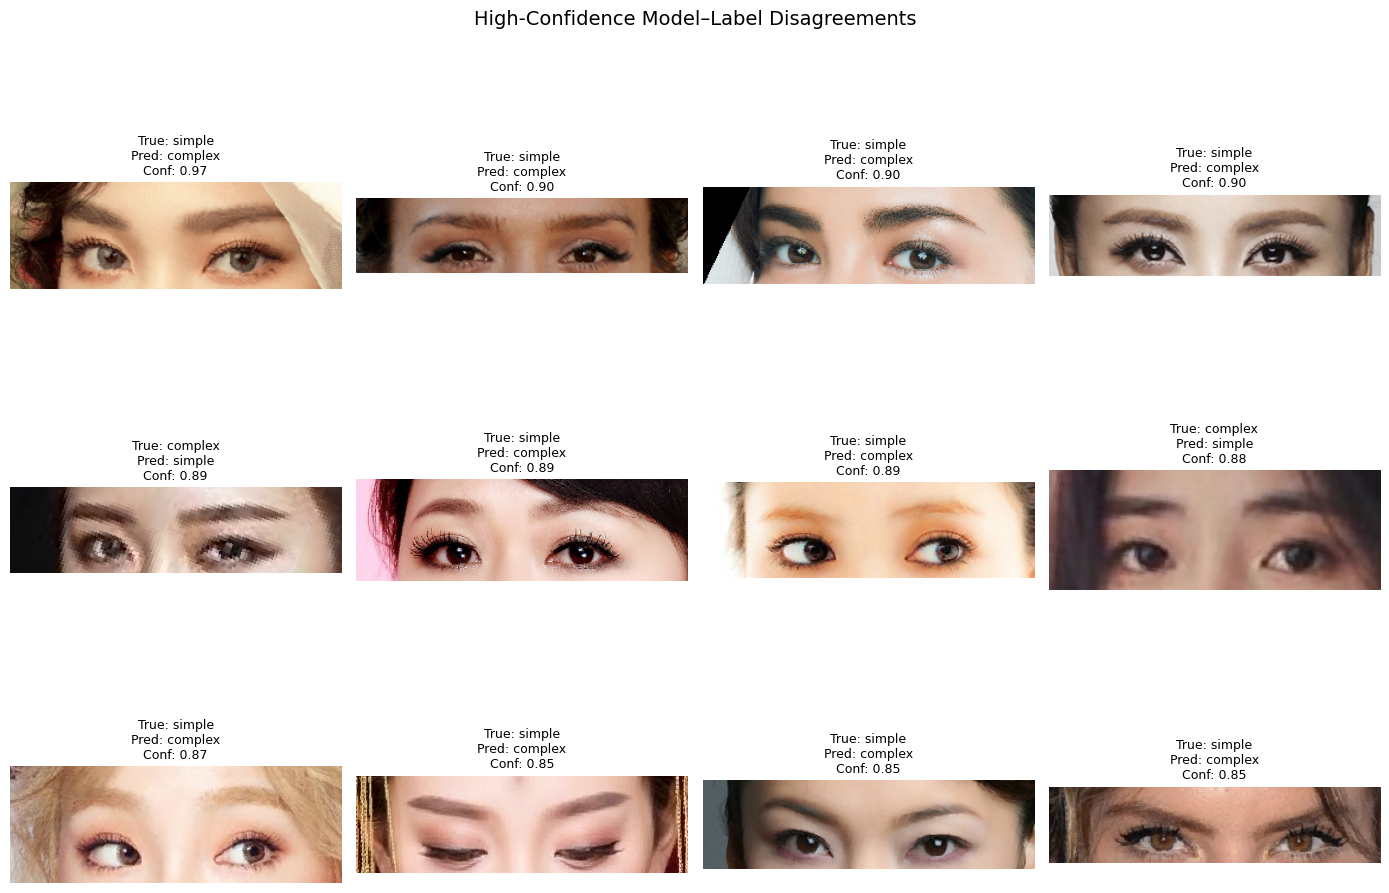

In [8]:
def show_high_confidence_disagreements(df, n=12):
    if len(df) == 0:
        print("No high-confidence disagreements found.")
        return

    examples = df.head(min(n, len(df)))

    cols = 4
    rows = (len(examples) + cols - 1) // cols

    plt.figure(figsize=(14, 3.5 * rows))

    for i, (_, ex) in enumerate(examples.iterrows()):
        img_path = os.path.join(IMG_DIR, ex["filename"])
        image = Image.open(img_path).convert("RGB")

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.axis("off")

        extra = ""
        if "original_complexity_score" in ex.index:
            extra = f"\nScore: {ex['original_complexity_score']}"

        plt.title(
            f"True: {ex['true_label']}\n"
            f"Pred: {ex['predicted_label']}\n"
            f"Conf: {ex['confidence_in_prediction']:.2f}"
            f"{extra}",
            fontsize=9
        )

    plt.suptitle(
        "High-Confidence Model–Label Disagreements",
        fontsize=14
      )
    plt.tight_layout()
    plt.show()

show_high_confidence_disagreements(high_confidence_errors, n=12)


In [9]:
# Load original eye count / label CSV
label_df = pd.read_csv('/content/complexity_labels_region_binary.csv')

# Keep only the columns we need
eye_info = label_df[['filename', 'eye_count', 'eye_label']].copy()

# Merge eye_count into the existing misclassified table
error_with_count = misclassified_df.merge(
    eye_info,
    on='filename',
    how='left'
)

print("Missing eye_count:", error_with_count['eye_count'].isna().sum())

# Show the first rows
display(
    error_with_count[
        [
            'filename',
            'eye_count',
            'eye_label',
            'true_label',
            'predicted_label',
            'P_complex',
            'confidence_in_prediction',
            'error_type'
        ]
    ].head(30)
)

# Count errors by eye_count
print("\nMisclassified examples by eye_count:")

count_table = (
    error_with_count
    .groupby(['error_type', 'eye_count'])
    .size()
    .unstack(fill_value=0)
)

display(count_table)

# Percentage distribution
print("\nPercentage distribution within each error type:")

percent_table = (
    count_table
    .div(count_table.sum(axis=1), axis=0)
    .mul(100)
    .round(1)
)

display(percent_table)

# High-confidence disagreements
high_conf_with_count = error_with_count[
    error_with_count['confidence_in_prediction'] >= 0.80
].sort_values(
    'confidence_in_prediction',
    ascending=False
)

print("\nHigh-confidence disagreements:")

display(
    high_conf_with_count[
        [
            'filename',
            'eye_count',
            'eye_label',
            'true_label',
            'predicted_label',
            'confidence_in_prediction',
            'error_type'
        ]
    ]
)

Missing eye_count: 0


,filename,eye_count,eye_label,true_label,predicted_label,P_complex,confidence_in_prediction,error_type
0,vFG590.png,3,simple,simple,complex,0.965320,0.965320,simple -> complex
1,XYH-068.png,3,simple,simple,complex,0.904321,0.904321,simple -> complex
2,vRX890.png,3,simple,simple,complex,0.902499,0.902499,simple -> complex
3,vHX711.png,3,simple,simple,complex,0.899129,0.899129,simple -> complex
4,vHX433.png,4,complex,complex,simple,0.108507,0.891493,complex -> simple
5,vRX98.png,3,simple,simple,complex,0.888238,0.888238,simple -> complex
6,vRX388.png,3,simple,simple,complex,0.886129,0.886129,simple -> complex
7,vHX675.png,4,complex,complex,simple,0.122214,0.877786,complex -> simple
8,vHX145.png,3,simple,simple,complex,0.872750,0.872750,simple -> complex
9,vFG178.png,3,simple,simple,complex,0.851803,0.851803,simple -> complex



Misclassified examples by eye_count:


eye_count,1,2,3,4,5,6,7
error_type,,,,,,,
complex -> simple,0,0,0,46,24,2,1
simple -> complex,2,30,89,0,0,0,0



Percentage distribution within each error type:


eye_count,1,2,3,4,5,6,7
error_type,,,,,,,
complex -> simple,0.0,0.0,0.0,63.0,32.9,2.7,1.4
simple -> complex,1.7,24.8,73.6,0.0,0.0,0.0,0.0



High-confidence disagreements:


,filename,eye_count,eye_label,true_label,predicted_label,confidence_in_prediction,error_type
0,vFG590.png,3,simple,simple,complex,0.965320,simple -> complex
1,XYH-068.png,3,simple,simple,complex,0.904321,simple -> complex
2,vRX890.png,3,simple,simple,complex,0.902499,simple -> complex
3,vHX711.png,3,simple,simple,complex,0.899129,simple -> complex
4,vHX433.png,4,complex,complex,simple,0.891493,complex -> simple
5,vRX98.png,3,simple,simple,complex,0.888238,simple -> complex
6,vRX388.png,3,simple,simple,complex,0.886129,simple -> complex
7,vHX675.png,4,complex,complex,simple,0.877786,complex -> simple
8,vHX145.png,3,simple,simple,complex,0.872750,simple -> complex
9,vFG178.png,3,simple,simple,complex,0.851803,simple -> complex


In [13]:
# ============================================================
# Validation error rate by eye_count
# ============================================================

# Total number of validation samples for each eye_count
total_by_count = (
    val_df
    .groupby('eye_count')
    .size()
    .rename('total_samples')
)

# Number of misclassified samples for each eye_count
errors_by_count = (
    error_with_count
    .groupby('eye_count')
    .size()
    .rename('errors')
)

# Combine totals and errors
error_rate_by_count = pd.concat(
    [total_by_count, errors_by_count],
    axis=1
).fillna(0)

error_rate_by_count['errors'] = (
    error_rate_by_count['errors'].astype(int)
)

# Calculate error rate
error_rate_by_count['error_rate_percent'] = (
    error_rate_by_count['errors']
    / error_rate_by_count['total_samples']
    * 100
).round(1)

print("Validation error rate by eye_count:")
display(error_rate_by_count)

Validation error rate by eye_count:


,total_samples,errors,error_rate_percent
eye_count,,,
1,10,2,20.0
2,58,30,51.7
3,138,89,64.5
4,190,46,24.2
5,123,24,19.5
6,19,2,10.5
7,6,1,16.7


errors are highly concentrated among samples with eye_count 2 and 3

Showing 20 random validation images with eye_count = 2


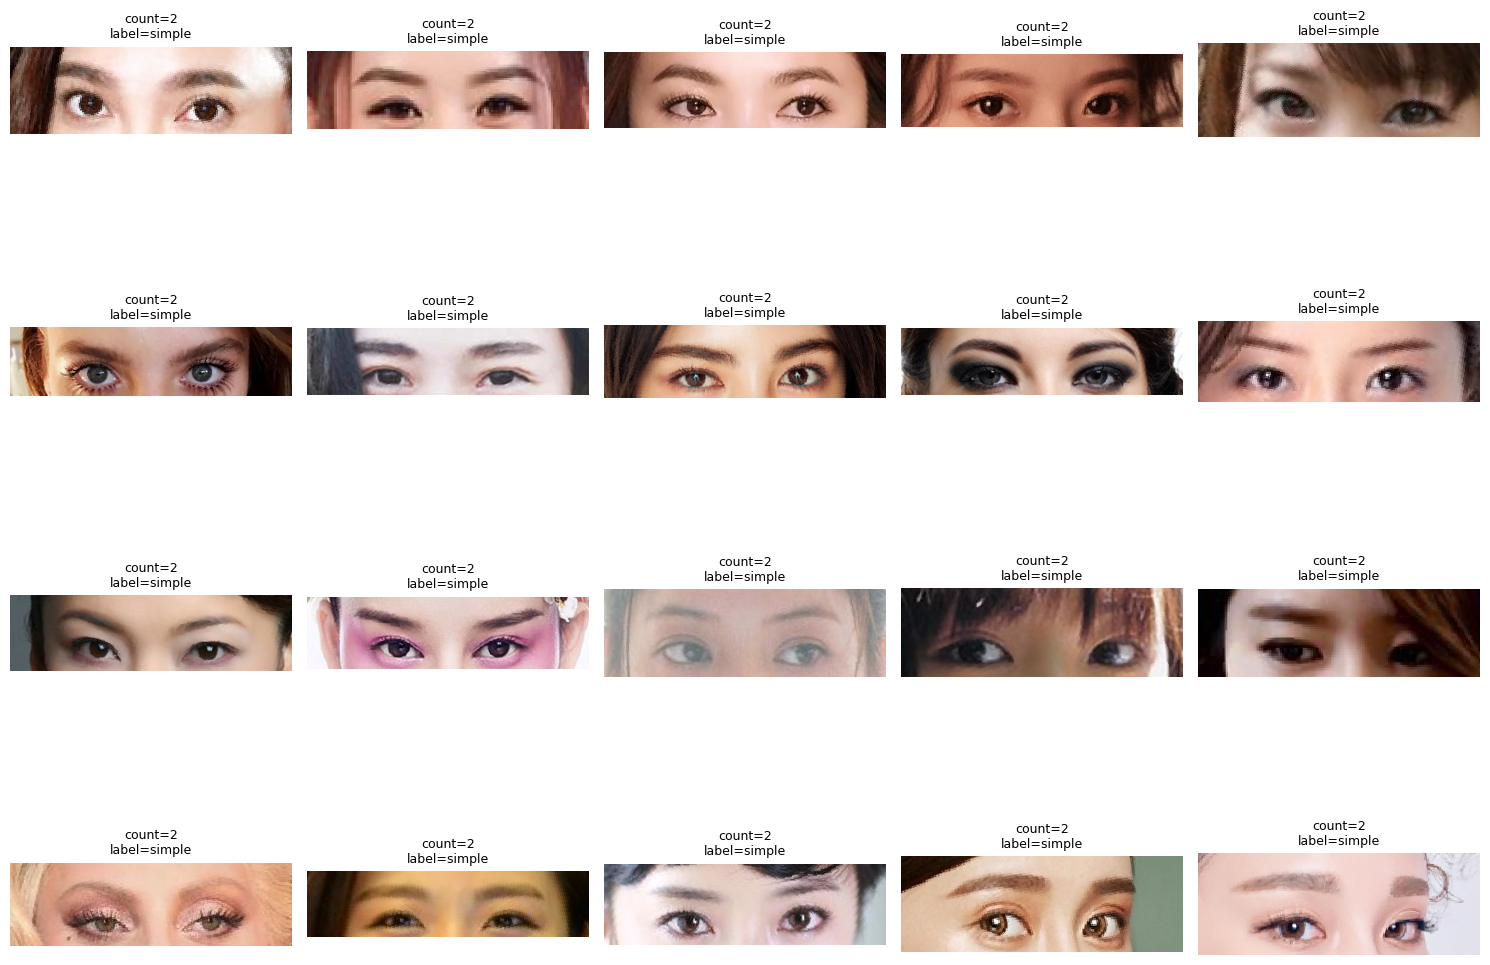

Showing 20 random validation images with eye_count = 3


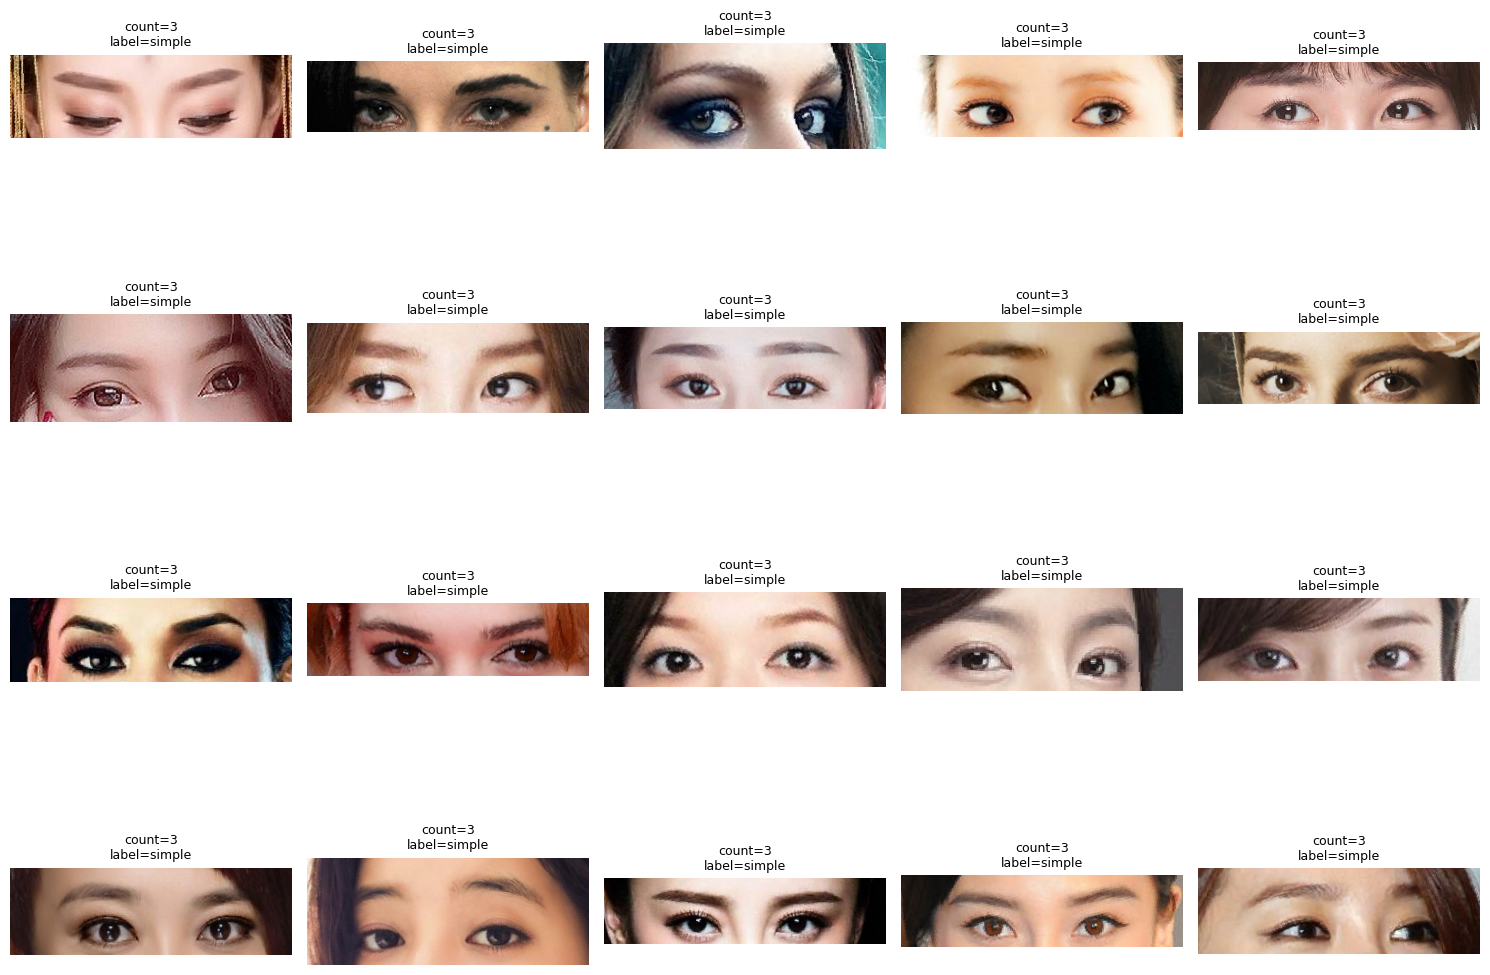

In [14]:
import matplotlib.pyplot as plt
import random
from PIL import Image

def show_random_eye_count_samples(df, eye_count_value, n=20):
    subset = df[df['eye_count'] == eye_count_value].copy()

    n = min(n, len(subset))
    sampled = subset.sample(n=n, random_state=42)

    print(f"Showing {n} random validation images with eye_count = {eye_count_value}")

    plt.figure(figsize=(15, 12))

    for i, (_, row) in enumerate(sampled.iterrows()):
        img = Image.open(row['image_path']).convert('RGB')

        plt.subplot(4, 5, i + 1)
        plt.imshow(img)
        plt.axis('off')

        plt.title(
            f"count={row['eye_count']}\n"
            f"label={row['eye_label']}",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


# Show eye_count = 2
show_random_eye_count_samples(val_df, eye_count_value=2, n=20)

# Show eye_count = 3
show_random_eye_count_samples(val_df, eye_count_value=3, n=20)

In [15]:
import json

# Load original GPT-4V descriptions
with open('/content/mt_text_anno.json', 'r') as f:
    mt_text = json.load(f)

# Add eye descriptions to validation dataframe
val_df['eye_description'] = val_df['filename'].apply(
    lambda x: mt_text.get(x, {}).get('eye', [])
)

# Add descriptions to misclassified dataframe
error_with_count['eye_description'] = error_with_count['filename'].apply(
    lambda x: mt_text.get(x, {}).get('eye', [])
)

display(
    error_with_count[
        [
            'filename',
            'eye_count',
            'true_label',
            'predicted_label',
            'confidence_in_prediction',
            'eye_description'
        ]
    ].head(30)
)

,filename,eye_count,true_label,predicted_label,confidence_in_prediction,eye_description
0,vFG590.png,3,simple,complex,0.965320,"[warm tones, mascara, shimmery eyeshadow]"
1,XYH-068.png,3,simple,complex,0.904321,"[winged liner, full lashes, defined eyebrows]"
2,vRX890.png,3,simple,complex,0.902499,"[Neutral tones, Mascara, Softly defined eyebrows]"
3,vHX711.png,3,simple,complex,0.899129,"[winged eyeliner, false lashes, mascara]"
4,vHX433.png,4,complex,simple,0.891493,"[smoky eyeshadow, winged eyeliner, full eyebro..."
5,vRX98.png,3,simple,complex,0.888238,"[false lashes, defined eyebrows, mascara]"
6,vRX388.png,3,simple,complex,0.886129,"[fluttery lashes, natural eyeshadow, subtle lo..."
7,vHX675.png,4,complex,simple,0.877786,"[soft eyeshadow, gentle liner, natural eyebrow..."
8,vHX145.png,3,simple,complex,0.872750,"[soft peach eyeshadow, winged eyeliner, mascara]"
9,vFG178.png,3,simple,complex,0.851803,"[neutral-toned eyeshadows, extended eyeliner, ..."


In [17]:
# Check available variables related to predictions/results
[name for name in globals().keys()
 if any(word in name.lower() for word in
        ['pred', 'result', 'error', 'val'])]

['val_tf',
 'val_df',
 'val_loader',
 'best_val_acc',
 'preds',
 'val_loss',
 'val_correct',
 'val_total',
 'all_preds',
 'val_loss_avg',
 'val_acc',
 'error_val_dataset',
 'pred',
 'show_error_examples',
 'high_confidence_errors',
 'error_with_count',
 'errors_by_count',
 'error_rate_by_count']

In [18]:
# ============================================================
# Compare CORRECT vs MISCLASSIFIED descriptions
# for eye_count = 2 and eye_count = 3
# ============================================================

import pandas as pd

# Check that predictions match the validation set size
print("Validation samples:", len(val_df))
print("Predictions:", len(all_preds))

assert len(val_df) == len(all_preds), \
    "Prediction count does not match validation set size."

# Create dataframe
comparison_df = val_df.copy().reset_index(drop=True)

# Convert numeric predictions:
# 0 = simple
# 1 = complex
comparison_df['predicted_label'] = [
    'complex' if int(p) == 1 else 'simple'
    for p in all_preds
]

# True label is already stored in val_df
comparison_df['true_label'] = comparison_df['eye_label']

# Correct / wrong
comparison_df['correct'] = (
    comparison_df['true_label']
    == comparison_df['predicted_label']
)

# Add original GPT-4V eye descriptions
comparison_df['eye_description'] = comparison_df['filename'].apply(
    lambda x: mt_text.get(x, {}).get('eye', [])
)

# ------------------------------------------------------------
# Compare eye_count = 2 and 3
# ------------------------------------------------------------

for count in [2, 3]:

    subset = comparison_df[
        comparison_df['eye_count'] == count
    ]

    correct = subset[subset['correct']]
    wrong = subset[~subset['correct']]

    print("\n" + "=" * 100)
    print(f"EYE COUNT = {count}")
    print("=" * 100)

    print("Total:", len(subset))
    print("Correct:", len(correct))
    print("Misclassified:", len(wrong))
    print(
        f"Error rate: {len(wrong) / len(subset) * 100:.1f}%"
    )

    print("\n--- RANDOM 15 CORRECT EXAMPLES ---")

    display(
        correct[
            [
                'filename',
                'eye_count',
                'true_label',
                'predicted_label',
                'eye_description'
            ]
        ].sample(
            min(15, len(correct)),
            random_state=42
        )
    )

    print("\n--- RANDOM 15 MISCLASSIFIED EXAMPLES ---")

    display(
        wrong[
            [
                'filename',
                'eye_count',
                'true_label',
                'predicted_label',
                'eye_description'
            ]
        ].sample(
            min(15, len(wrong)),
            random_state=42
        )
    )

Validation samples: 544
Predictions: 544

EYE COUNT = 2
Total: 58
Correct: 28
Misclassified: 30
Error rate: 51.7%

--- RANDOM 15 CORRECT EXAMPLES ---


,filename,eye_count,true_label,predicted_label,eye_description
212,vRX745.png,2,simple,simple,"[subtle eyeshadow, lightly defined lashes]"
489,vFG348.png,2,simple,simple,"[soft definition, natural tones]"
136,vFG277.png,2,simple,simple,"[soft smokey, warm tones]"
389,vRX256.png,2,simple,simple,"[natural look, mascara]"
62,vHX67.png,2,simple,simple,"[soft eyeliner, feathered brows]"
282,vRX838.png,2,simple,simple,"[soft smudging, curled lashes]"
338,vHX519.png,2,simple,simple,"[natural look, subtle eyeliner]"
416,vHX285.png,2,simple,simple,"[soft brown eyeshadow, long lashes]"
253,vHX325.png,2,simple,simple,"[natural shades, mascara]"
295,vRX733.png,2,simple,simple,"[lightly lined upper lid, groomed eyebrows]"



--- RANDOM 15 MISCLASSIFIED EXAMPLES ---


,filename,eye_count,true_label,predicted_label,eye_description
450,XMY-431.png,2,simple,complex,"[winged eyeliner, arched eyebrows]"
271,vRX572.png,2,simple,complex,"[neutral eyeshadow, defined eyebrows]"
392,vHX123.png,2,simple,complex,"[natural shades, groomed eyebrows]"
323,vHX379.png,2,simple,complex,"[winged eyeliner, mascara]"
105,vRX551.png,2,simple,complex,"[lightly defined eyeliner, softly enhanced las..."
123,f30487978c587a5f18dfa4d42fc6ccc0.png,2,simple,complex,"[winged eyeliner, false lashes]"
467,XYH-156.png,2,simple,complex,"[defined lashes, mascara]"
395,XYH-107.png,2,simple,complex,"[smoky eyeshadow, well-defined eyebrows]"
226,XMY-373.png,2,simple,complex,"[defined lashes, neutral tones]"
7,vHX425.png,2,simple,complex,"[neutral eyeshadow, mascara]"



EYE COUNT = 3
Total: 138
Correct: 49
Misclassified: 89
Error rate: 64.5%

--- RANDOM 15 CORRECT EXAMPLES ---


,filename,eye_count,true_label,predicted_label,eye_description
130,vRX43.png,3,simple,simple,"[natural shades, soft eyeliner, lightly mascar..."
510,vRX384.png,3,simple,simple,"[soft eyeliner, natural lashes, lightly filled..."
513,vRX451.png,3,simple,simple,"[soft eyeshadow, natural lashes, defined brows]"
502,vHX668.png,3,simple,simple,"[subtle eyeliner, defined eyebrows, mascara]"
159,vHX75.png,3,simple,simple,"[soft eyeliner, defined eyebrows, mascara]"
275,vFG456.png,3,simple,simple,"[defined eyeliner, lengthening mascara, groome..."
269,vHX298.png,3,simple,simple,"[natural look, lightly defined lashes, soft ey..."
266,vHX217.png,3,simple,simple,"[soft brown eyeshadow, light eyeliner, defined..."
349,vRX236.png,3,simple,simple,"[soft pink eyeshadow, light eyeliner, defined ..."
211,vHX446.png,3,simple,simple,"[black eyeliner, softly defined eyebrows, natu..."



--- RANDOM 15 MISCLASSIFIED EXAMPLES ---


,filename,eye_count,true_label,predicted_label,eye_description
283,vHX34.png,3,simple,complex,"[winged eyeliner, soft eyeshadow, defined eyeb..."
321,vRX574.png,3,simple,complex,"[subtle eyeliner, softly defined crease, light..."
207,vRX662.png,3,simple,complex,"[black eyeliner, mascara, softly lined lower l..."
68,vHX463.png,3,simple,complex,"[winged eyeliner, defined eyebrows, mascara]"
298,vHX231.png,3,simple,complex,"[mascara, neutral eyeshadow, brown tones]"
2,vHX553.png,3,simple,complex,"[soft brown eyeshadow, winged eyeliner, full e..."
423,vHX592.png,3,simple,complex,"[soft eyeshadow, winged eyeliner, long lashes]"
133,vRX783.png,3,simple,complex,"[natural tones, light mascara, gently defined ..."
65,vRX321.png,3,simple,complex,"[natural, light mascara, subtle eyeshadow]"
150,vFG231.png,3,simple,complex,"[defined eyebrows, eyeliner with a slight wing..."


In [19]:
# ============================================================
# Quantitative keyword analysis:
# Correct vs Misclassified descriptions
# for eye_count = 2 and 3
# ============================================================

keywords = {
    'natural': ['natural'],
    'soft': ['soft'],
    'subtle': ['subtle'],
    'light': ['light'],
    'minimal': ['minimal'],

    'winged': ['winged'],
    'smoky': ['smoky', 'smokey'],
    'false_lashes': ['false lash', 'false eyelashes'],
    'dramatic': ['dramatic'],
    'shimmer': ['shimmer', 'shimmery'],
    'dark': ['dark'],
    'extended_liner': ['extended eyeliner', 'extended liner'],
    'defined': ['defined']
}

def description_to_text(desc):
    if isinstance(desc, list):
        return ' '.join(desc).lower()
    return str(desc).lower()

def keyword_percentage(df, terms):
    if len(df) == 0:
        return 0

    matches = 0

    for desc in df['eye_description']:
        text = description_to_text(desc)

        if any(term in text for term in terms):
            matches += 1

    return matches / len(df) * 100


rows = []

for count in [2, 3]:

    subset = comparison_df[
        comparison_df['eye_count'] == count
    ]

    correct = subset[subset['correct']]
    wrong = subset[~subset['correct']]

    for keyword_name, terms in keywords.items():

        correct_pct = keyword_percentage(correct, terms)
        wrong_pct = keyword_percentage(wrong, terms)

        rows.append({
            'eye_count': count,
            'keyword': keyword_name,
            'correct_%': round(correct_pct, 1),
            'misclassified_%': round(wrong_pct, 1),
            'difference_wrong_minus_correct': round(
                wrong_pct - correct_pct, 1
            )
        })


keyword_results = pd.DataFrame(rows)

display(keyword_results)

,eye_count,keyword,correct_%,misclassified_%,difference_wrong_minus_correct
0,2,natural,46.4,33.3,-13.1
1,2,soft,35.7,20.0,-15.7
2,2,subtle,10.7,0.0,-10.7
3,2,light,42.9,23.3,-19.5
4,2,minimal,7.1,0.0,-7.1
5,2,winged,0.0,30.0,30.0
6,2,smoky,3.6,3.3,-0.2
7,2,false_lashes,0.0,6.7,6.7
8,2,dramatic,0.0,0.0,0.0
9,2,shimmer,0.0,6.7,6.7
